# Does de-censoring hurt Slovene skills more? (RQ3 capability control)

This notebook is a runnable walkthrough of artifact **`art_Q-LED_B1t1VK`** (iter-3, experiment 12). It asks whether an
**English-objective Heretic abliteration edit** (a refusal-removal LoRA) costs more *capability* in **Slovene** than in
**English**. It compares two sibling 12B models run through the same code path (NF4):
**GaMS3-12B-Instruct** (Slovene continued pre-training of Gemma 3) and **Gemma-3-12B-IT**.

**Conditions** (all scored on identical, row-paired EN/SL items):
* `orig`: the unedited model.
* `E_iter1`: the iter-1 selected Heretic edit (λ = 1).
* `E_art2`: artifact 2's B′ edit selection.
* `rand_nm_j*`: **norm-matched random-direction edits**, built by Heretic's own `abliterate()` with the *same*
  parameters, where only the directions are random. This control separates "the refusal direction hurts X" from
  "any perturbation of this size hurts X".

**Primary metric.** The headroom-normalised change `H = (acc_cond − chance)/(acc_orig − chance) − 1`, macro-averaged
over tasks with headroom ≥ 0.10, with a paired bootstrap. The two derived quantities are `A = H_SL − H_EN`
(does Slovene lose more?) and `I = A_GaMS − A_Gemma` (is it worse for the Slovene-adapted model?). The **catastrophe
gate** flags any macro loss > 0.20.

**What runs here.** The original `method.py` is an orchestrator. It calls GPU scripts (`src/gpu_block.py`, about 4 h on
an L4 with two 12B models) and then the CPU analysis (`src/analyze.py`). In the notebook:
1. `method.py` is shown verbatim, in **dry-run** mode. It prints the exact pipeline it would launch.
2. The **utility-analysis core** of `src/analyze.py` (`load_util → build_vectors → util_block → gates_from`) runs
   unchanged on the saved per-item lm-eval outputs of a small paired subset (`mini_demo_data.json`).
3. The last cell compares the demo numbers with the full-run reference (300 items × 6 tasks × 2 languages).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (version from the artifact's env/requirements.lock.txt)
_pip('loguru==0.7.3')

# numpy, scipy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# --- original method.py import block ---
from __future__ import annotations

import argparse
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- original src/analyze.py imports (the analysis step method.py runs last) ---
import json
import math
from collections import defaultdict

import numpy as np
from scipy.stats import binomtest

# --- notebook-only: results table + figures ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-2cf2a7-does-slovene-taught-refusal-survive/fork/run_spusA3PNmaY6/round-3/experiment-12/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("examples:", len(data["examples"]))
ex = data["examples"][0]
print("\nfirst item:", ex["metadata_task"], ex["metadata_lang"], "| gold =", ex["output"])
print(ex["input"])
print({k: v for k, v in ex.items() if k.startswith("predict_")})

Curated demo subset of art_Q-LED_B1t1VK: 8 randomly sampled (seed 20260925) row-paired EN/SL items per task for the 6 utility tasks (ARC-C, BoolQ, HellaSwag, OBQA, PIQA, Winogrande) with per-item lm-eval correctness and logliks for GaMS3-12B-Instruct and Gemma-3-12B-IT under orig / E_iter1 / E_art2 / rand_nm_j1 / rand_nm_j2. EN and SL rows share metadata_pair_id and appear in the same pair order.
examples: 96

first item: arc_challenge en | gold = 2
Question: Which is the best piece of equipment to determine the topography of the United States?
Answer:
(0) radar
(1) compass
(2) satellite
(3) radio
{'predict_gams3_it__E_art2': '2', 'predict_gams3_it__E_iter1': '2', 'predict_gams3_it__orig': '2', 'predict_gams3_it__rand_nm_j1': '2', 'predict_gemma_it__E_art2': '2', 'predict_gemma_it__E_iter1': '2', 'predict_gemma_it__orig': '2', 'predict_gemma_it__rand_nm_j1': '2', 'predict_gemma_it__rand_nm_j2': '2'}


## Configuration

Every tunable parameter lives here. `STEPS`, `MINUTES_PER_MODEL` and `N_GEN` are `method.py`'s argparse defaults.
`N_BOOT`, `SEED`, `HEADROOM_FLOOR` and `GATE_LOSS` come from `src/common.py`. `N_PAIRS_PER_TASK` sets how many
EN/SL item **pairs** per task enter the analysis. The full run used 300. The demo file holds 8 per task, so the
demo's numbers are **much noisier** than the full run's and only illustrate the computation.

In [5]:
# ---- method.py orchestration arguments (original defaults) ----
STEPS = "prep,mt,protocol,gams,gemma,analyze"
MINUTES_PER_MODEL = 100.0
N_GEN = 100
DRY_RUN = True          # GPU steps need 2x12B NF4 models, HF_TOKEN and ~4 h on a 24 GB GPU -> only print the plan

# ---- analysis parameters (src/common.py) ----
N_BOOT = 2000            # original: 2000 paired-bootstrap draws
N_PAIRS_PER_TASK = 8     # original: 300 row-paired EN/SL items per task (mini_demo_data.json holds 8)
SEED = 20260925
HEADROOM_FLOOR = 0.10   # tasks with acc_orig - chance < 0.10 are excluded from the macro
GATE_LOSS = 0.20        # catastrophe threshold on the macro headroom-normalised loss

## 1. The orchestrator: `method.py`

This is `method.py` as written. Each step is a resumable script under `src/`, and `method.py` only runs them in order:

| step | script | what it does |
|---|---|---|
| 1 | `src/prep_data.py` | 300 row-paired EN/SL items × 6 tasks; Belebele EN/SL/HU; a fresh Dolly harmless set; FLORES passages |
| 1c | `src/prep_mt.py` | NLLB-200 machine translation of the harmless set (+ chrF gate) |
| 2 | `src/write_protocol.py` | protocol freeze (sha256 + git commit) **before** any edited-condition forward pass |
| 3–4 | `src/gpu_block.py` | per model: build edits + random controls, then lm-eval utility, KL, generations, Belebele, BPB |
| 6–10 | `src/analyze.py`, `audit.py`, … | headroom H, macros, A, I, gates, KL ratios; independent re-audit; outputs |

Notebook changes, and nothing else: `WS` is the current directory because notebooks have no `__file__`; the
log-file sink is dropped; `run()` returns early when `DRY_RUN` is set; `parse_args` gets the config values instead
of reading the CLI.

In [6]:
"""RQ3 capability control — single entry point. (method.py)"""
WS = Path.cwd()  # notebook: was Path(__file__).resolve().parent
PY = str(WS / ".venv" / "bin" / "python")
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# notebook: file sink logs/method.log dropped

GPU_STAGES = "util,kl,gen,belebele,bpb,scorer2,chat"


def run(args: list[str]) -> None:
    logger.info("RUN " + " ".join(args))
    if DRY_RUN:  # notebook: the src/ scripts need the full workspace + GPUs; only show what would run
        return
    t = time.time()
    r = subprocess.run([PY] + args, cwd=WS)
    logger.info(f"exit {r.returncode} after {time.time() - t:.0f}s")
    if r.returncode != 0:
        raise RuntimeError(f"step failed: {args}")


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--steps", default="prep,mt,protocol,gams,gemma,analyze")
    ap.add_argument("--minutes-per-model", type=float, default=100.0)
    ap.add_argument("--n-gen", type=int, default=100)
    a = ap.parse_args(["--steps", STEPS, "--minutes-per-model", str(MINUTES_PER_MODEL), "--n-gen", str(N_GEN)])  # notebook: no CLI
    steps = a.steps.split(",")
    if "prep" in steps:
        run(["src/prep_data.py"])
    if "mt" in steps:
        run(["src/prep_mt.py"])
    if "protocol" in steps:
        run(["src/write_protocol.py"])
    for m, key in (("gams3_it", "gams"), ("gemma_it", "gemma")):  # GaMS first (artifact 2's Gemma selection gets more time)
        if key in steps:
            dl = int(time.time() + a.minutes_per_model * 60)
            run(["src/gpu_block.py", "--model", m, "--stages", "pilot," + GPU_STAGES, "--n-gen", str(a.n_gen),
                 "--n-gen-lambda", "50", "--util-bs", "8",
                 "--lambda-conds", "orig,E_iter1,E_iter1_l2.0,E_iter1_l1.5,E_iter1_l0.5", "--deadline-epoch", str(dl)])
    if "analyze" in steps:
        for s in ("src/analyze.py", "src/audit.py", "src/assemble_p0.py", "src/build_outputs.py", "src/make_figs.py"):
            run([s])


main()

18:31:55|INFO   |RUN src/prep_data.py


18:31:55|INFO   |RUN src/prep_mt.py


18:31:55|INFO   |RUN src/write_protocol.py


18:31:55|INFO   |RUN src/gpu_block.py --model gams3_it --stages pilot,util,kl,gen,belebele,bpb,scorer2,chat --n-gen 100 --n-gen-lambda 50 --util-bs 8 --lambda-conds orig,E_iter1,E_iter1_l2.0,E_iter1_l1.5,E_iter1_l0.5 --deadline-epoch 1790367115


18:31:55|INFO   |RUN src/gpu_block.py --model gemma_it --stages pilot,util,kl,gen,belebele,bpb,scorer2,chat --n-gen 100 --n-gen-lambda 50 --util-bs 8 --lambda-conds orig,E_iter1,E_iter1_l2.0,E_iter1_l1.5,E_iter1_l0.5 --deadline-epoch 1790367115


18:31:55|INFO   |RUN src/analyze.py


18:31:55|INFO   |RUN src/audit.py


18:31:55|INFO   |RUN src/assemble_p0.py


18:31:55|INFO   |RUN src/build_outputs.py


18:31:55|INFO   |RUN src/make_figs.py


## 2. Shared constants and helpers (`src/common.py`)

These are copied verbatim, except that the numeric constants now come from the config cell. `headroom_H` is the
primary metric. `gate_verdict` is the catastrophe rule: **CATASTROPHIC** if the point loss exceeds the threshold,
**POSSIBLY_CATASTROPHIC** if only the 95% upper bound does, **OK** otherwise.

In [7]:
MODELS = {
    "gams3_it": {"repo": "cjvt/GaMS3-12B-Instruct", "revision": "1d0b27af5748784482600d24779409e7e1dc9adc"},
    "gemma_it": {"repo": "google/gemma-3-12b-it", "revision": "96b6f1eccf38110c56df3a15bffe176da04bfd80"},
}

UTIL_TASKS = ["arc_challenge", "boolq", "hellaswag", "openbookqa", "piqa", "winogrande"]
# lm-eval convention: acc_norm for ARC-C/HellaSwag/OBQA/PIQA; acc for BoolQ/Winogrande/Belebele
PRIMARY_METRIC = {"arc_challenge": "acc_norm", "hellaswag": "acc_norm", "openbookqa": "acc_norm", "piqa": "acc_norm",
                  "boolq": "acc", "winogrande": "acc", "belebele": "acc"}


def headroom_H(acc_cond: float, acc_orig: float, chance: float) -> float:
    """Headroom-normalised delta: (acc_cond - chance)/(acc_orig - chance) - 1. Loss = -H."""
    den = acc_orig - chance
    if abs(den) < 1e-12:
        return float("nan")
    return (acc_cond - chance) / den - 1.0


def gate_verdict(loss_point: float, loss_hi95: float, threshold: float = GATE_LOSS) -> str:
    """CATASTROPHIC if point loss > threshold; POSSIBLY_CATASTROPHIC if only the 95% upper bound exceeds it."""
    if loss_point is None or (isinstance(loss_point, float) and math.isnan(loss_point)):
        return "PENDING"
    if loss_point > threshold:
        return "CATASTROPHIC"
    if loss_hi95 > threshold:
        return "POSSIBLY_CATASTROPHIC"
    return "OK"


RNG_SEED = SEED + 1
MODEL_LIST = list(MODELS)


def pct(a: np.ndarray, q: float) -> float:
    return float(np.percentile(a, q))


def ci(a: np.ndarray, level: int = 95) -> list[float]:
    lo = (100 - level) / 2
    return [round(pct(a, lo), 5), round(pct(a, 100 - lo), 5)]

## 3. Loading the per-item lm-eval outputs (`load_util`, `item_order`)

In the full pipeline, `gpu_block.py` writes one jsonl row per (model, condition, language, task, item) to
`results/items/util_*.jsonl`, and the analysis reads them back into
`U[model][cond][(lang, task)][item_id] = (correct, 1/n_choices, pair_id)`.

The demo JSON stores the same information in the published `method_out` format: one example per item with a
`metadata_correct_<model>__<cond>` flag and the per-choice logliks. `_util_rows` below is the only new helper. It
turns each example back into the original row format and keeps the first `N_PAIRS_PER_TASK` pairs of every task.
`load_util` itself is unchanged. `item_order` returns the paired order, so EN and SL vectors stay aligned by `pair_id`.

In [8]:
def _util_rows(kind: str) -> list[dict]:
    """notebook: rebuild results/items/{kind}_*.jsonl rows from the demo JSON (method_out format)."""
    keep = {}
    for e in data["examples"]:  # first N_PAIRS_PER_TASK pair ids per task, in paired order
        ids = keep.setdefault(e["metadata_task"], [])
        if e["metadata_pair_id"] not in ids and len(ids) < N_PAIRS_PER_TASK:
            ids.append(e["metadata_pair_id"])
    rows = []
    for e in data["examples"]:
        if e["metadata_pair_id"] not in keep[e["metadata_task"]]:
            continue
        for k, v in e.items():
            if not k.startswith("metadata_correct_"):
                continue
            model, cond = k[len("metadata_correct_"):].split("__")
            rows.append({"model": model, "cond": cond, "task": e["metadata_task"], "lang": e["metadata_lang"],
                         "item_id": e["metadata_item_id"], "pair_id": e["metadata_pair_id"],
                         PRIMARY_METRIC[e["metadata_task"]]: v, "n_choices": len(e[f"metadata_lls_{model}__{cond}"])})
    return rows


def load_util(kind: str) -> dict:
    """-> U[model][cond][lang][task] = {item_id: correct(primary metric)}"""
    U: dict = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
    for r in _util_rows(kind):  # notebook: was `for f in sorted(ITEMS.glob(...)): for r in read_jsonl(f):`
        metric = PRIMARY_METRIC[r["task"]]
        U[r["model"]][r["cond"]][(r["lang"], r["task"])][r["item_id"]] = (float(r[metric]), 1.0 / r["n_choices"],
                                                                            r.get("pair_id"))
    return U


def item_order(task: str, lang: str) -> list[str]:
    # notebook: was the row order of data/util/{task}_{lang}.jsonl (row-paired EN/SL) -> same order in the demo JSON
    return [e["metadata_item_id"] for e in data["examples"] if e["metadata_task"] == task and e["metadata_lang"] == lang]


U = load_util("util")
for m in U:
    print(m, {c: sum(len(v) for v in U[m][c].values()) for c in U[m]})

gams3_it {'E_art2': 96, 'E_iter1': 96, 'orig': 96, 'rand_nm_j1': 96}
gemma_it {'E_art2': 96, 'E_iter1': 96, 'orig': 96, 'rand_nm_j1': 96, 'rand_nm_j2': 96}


## 4. Aligned vectors and the joint paired bootstrap (`build_vectors`, `boot_indices`)

`build_vectors` intersects the item ids present in `orig` and in every condition, then orders them by pair. The
**same resampled pair indices** are then used for every condition, both languages and both models within a task.
That is what makes `A = H_SL − H_EN` and `I = A_GaMS − A_Gemma` *paired* contrasts and not differences of
independent estimates.

In [9]:
def build_vectors(U: dict, model: str, conds: list[str], cells: list[tuple[str, str]]) -> dict:
    """Aligned vectors over the item ids present in orig AND every cond (intersection), per (lang, task) cell.
    Paired tasks: EN/SL share pair_id -> the SAME pair order is used in both languages."""
    out = {}
    for lang, task in cells:
        if (lang, task) not in U[model].get("orig", {}):
            continue
        common = None
        for c in ["orig"] + conds:
            ids = set(U[model].get(c, {}).get((lang, task), {}).keys())
            common = ids if common is None else common & ids
        order = [i for i in item_order(task, lang) if i in common]
        if not order:
            continue
        vec = {c: np.array([U[model][c][(lang, task)][i][0] for i in order]) for c in ["orig"] + conds}
        chance = float(np.mean([U[model]["orig"][(lang, task)][i][1] for i in order]))
        out[(lang, task)] = {"ids": order, "vec": vec, "chance": chance}
    return out


def boot_indices(n: int, rng: np.random.Generator, B: int = N_BOOT) -> np.ndarray:
    return rng.integers(0, n, size=(B, n))

## 5. The utility block (`util_block`)

This is the core of the analysis, copied verbatim. For every model × condition × language × task cell it computes:
* the accuracies, the headroom `acc_orig − chance`, `H` with its bootstrap CI, and the raw percentage-point change;
* McNemar's exact test on the discordant items, Holm-corrected within model × condition.

It then aggregates:
* **macros**: mean `H` over eligible tasks (headroom ≥ 0.10), `macro_loss = −H` and its 95% upper bound; the raw-pp
  macro; the F6 fallback flag (≥ 3 ineligible tasks → judge on raw pp);
* **A** = `H_SL − H_EN` per model × condition;
* **interaction I** = `A_GaMS − A_Gemma` per condition;
* **random-adjusted** `H_excess` = `H(edit) − H(rand_nm_j1)`, i.e. the damage beyond a norm-matched random edit.

In [10]:
def util_block(U: dict, conds_all: list[str], langs: list[str], tasks: list[str], label: str, rng_seed: int) -> dict:
    """Compute H per cell, macros, A, I, H_excess with a joint paired bootstrap (same resampled pair indices across
    conditions, languages and models within a task)."""
    rng = np.random.default_rng(rng_seed)
    cells = [(l, t) for l in langs for t in tasks]
    V = {m: build_vectors(U, m, [c for c in conds_all if c in U[m]], cells) for m in MODEL_LIST if m in U}
    # shared bootstrap indices per task: need the same n across models/languages -> use pair-index intersection
    idx = {}
    for t in tasks:
        ns = [len(V[m][(l, t)]["ids"]) for m in V for l in langs if (l, t) in V[m]]
        if not ns:
            continue
        if len(set(ns)) != 1:
            logger.warning(f"{label}/{t}: unequal n across cells {ns}; bootstrap per-cell independent for this task")
            idx[t] = None
        else:
            idx[t] = boot_indices(ns[0], rng)
    table: dict = {}
    boots: dict = {}
    for m in V:
        conds = [c for c in conds_all if c in U[m] and c != "orig"]
        table[m] = {}
        for c in conds:
            table[m][c] = {}
            for l in langs:
                table[m][c][l] = {}
                for t in tasks:
                    cell = V[m].get((l, t))
                    if cell is None or c not in cell["vec"]:
                        continue
                    vo, vc, ch = cell["vec"]["orig"], cell["vec"][c], cell["chance"]
                    ao, ac = float(vo.mean()), float(vc.mean())
                    H = headroom_H(ac, ao, ch)
                    ix = idx.get(t) if idx.get(t) is not None else boot_indices(len(vo), rng)
                    bo, bc = vo[ix].mean(1), vc[ix].mean(1)
                    with np.errstate(divide="ignore", invalid="ignore"):
                        bH = (bc - ch) / (bo - ch) - 1
                    b_ = int(((vo == 1) & (vc == 0)).sum())
                    c_ = int(((vo == 0) & (vc == 1)).sum())
                    p_mc = float(binomtest(min(b_, c_), b_ + c_, 0.5).pvalue) if b_ + c_ > 0 else 1.0
                    table[m][c][l][t] = {"acc_orig": round(ao, 5), "acc": round(ac, 5), "acc_metric": PRIMARY_METRIC[t],
                                         "chance": round(ch, 5), "headroom": round(ao - ch, 5), "H": round(H, 5),
                                         "H_ci95": ci(bH[np.isfinite(bH)]), "raw_pp": round(100 * (ac - ao), 3),
                                         "rel_pct": round(100 * (ac / ao - 1), 3) if ao > 0 else None, "n": len(vo),
                                         "eligible": bool(ao - ch >= HEADROOM_FLOOR - 1e-9), "mcnemar_b_orig_right_cond_wrong": b_,
                                         "mcnemar_c_orig_wrong_cond_right": c_, "mcnemar_p": p_mc}
                    boots[(m, c, l, t)] = (bH, (bc - bo) * 100)
                # Holm within condition happens after all langs
            # Holm-correct McNemar within model x condition
            ps = [(l, t, table[m][c][l][t]["mcnemar_p"]) for l in table[m][c] for t in table[m][c][l]]
            order = sorted(range(len(ps)), key=lambda k: ps[k][2])
            running = 0.0
            for rank, k in enumerate(order):
                adj = min(1.0, (len(ps) - rank) * ps[k][2])
                running = max(running, adj)
                l, t, _ = ps[k]
                table[m][c][l][t]["mcnemar_p_holm"] = round(running, 6)
    # macros
    macros: dict = {}
    macro_boot: dict = {}
    RAW_H: dict = {}
    for m in table:
        macros[m] = {}
        for c in table[m]:
            macros[m][c] = {}
            for l in langs:
                cells_l = table[m][c].get(l, {})
                if not cells_l:
                    continue
                elig = [t for t in cells_l if cells_l[t]["eligible"]]
                inel = [t for t in cells_l if not cells_l[t]["eligible"]]
                Hm = float(np.mean([cells_l[t]["H"] for t in elig])) if elig else float("nan")
                bHm = np.mean([boots[(m, c, l, t)][0] for t in elig], axis=0) if elig else np.full(N_BOOT, np.nan)
                raw = float(np.mean([cells_l[t]["raw_pp"] for t in cells_l]))
                braw = np.mean([boots[(m, c, l, t)][1] for t in cells_l], axis=0)
                rel = float(np.mean([cells_l[t]["rel_pct"] for t in cells_l if cells_l[t]["rel_pct"] is not None]))
                macro_boot[(m, c, l)] = (bHm, braw)
                RAW_H[(m, c, l)] = Hm
                macros[m][c][l] = {"macro_H": round(Hm, 5), "macro_H_ci95": ci(bHm[np.isfinite(bHm)]) if elig else None,
                                   "macro_H_ci90": ci(bHm[np.isfinite(bHm)], 90) if elig else None,
                                   "macro_loss": round(-Hm, 5), "macro_loss_hi95": round(-pct(bHm[np.isfinite(bHm)], 2.5), 5) if elig else None,
                                   "eligible_tasks": elig, "ineligible_tasks": inel, "raw_pp_macro": round(raw, 4),
                                   "raw_pp_macro_ci95": ci(braw), "rel_pct_macro": round(rel, 4),
                                   "F6_raw_pp_rule": len(inel) >= 3}
            if all(l in macros[m][c] for l in ("en", "sl")) and len(langs) >= 2:
                pooled = (macro_boot[(m, c, "en")][0] + macro_boot[(m, c, "sl")][0]) / 2
                A = macro_boot[(m, c, "sl")][0] - macro_boot[(m, c, "en")][0]
                macros[m][c]["pooled_macro_H"] = round((RAW_H[(m, c, "en")] + RAW_H[(m, c, "sl")]) / 2, 5)
                macros[m][c]["pooled_macro_H_ci95"] = ci(pooled[np.isfinite(pooled)])
                macros[m][c]["A_sl_minus_en"] = round(RAW_H[(m, c, "sl")] - RAW_H[(m, c, "en")], 5)
                macros[m][c]["A_ci95"] = ci(A[np.isfinite(A)])
                macros[m][c]["A_ci90"] = ci(A[np.isfinite(A)], 90)
    # interaction and random-adjusted
    inter: dict = {}
    if len(macros) == 2:
        mg, mm = "gams3_it", "gemma_it"
        for c in set(macros.get(mg, {})) & set(macros.get(mm, {})):
            if "A_sl_minus_en" in macros[mg][c] and "A_sl_minus_en" in macros[mm][c]:
                bA = {m: macro_boot[(m, c, "sl")][0] - macro_boot[(m, c, "en")][0] for m in (mg, mm)}
                bI = bA[mg] - bA[mm]
                inter[c] = {"I": round((RAW_H[(mg, c, "sl")] - RAW_H[(mg, c, "en")]) - (RAW_H[(mm, c, "sl")] - RAW_H[(mm, c, "en")]), 5),
                            "I_ci95": ci(bI[np.isfinite(bI)]), "I_ci90": ci(bI[np.isfinite(bI)], 90),
                            "note": "resolution limit ~0.10-0.12 of headroom (80% power, alpha .05); |I| below it is an estimate, not 'no asymmetry'"}
    excess: dict = {}
    for m in macros:
        for c in macros[m]:
            if c.startswith("E_") and "rand_nm_j1" in macros[m]:
                excess.setdefault(m, {})[c] = {}
                for l in langs:
                    if l in macros[m][c] and l in macros[m]["rand_nm_j1"]:
                        b = macro_boot[(m, c, l)][0] - macro_boot[(m, "rand_nm_j1", l)][0]
                        excess[m][c][l] = {"H_excess": round(RAW_H[(m, c, l)] - RAW_H[(m, "rand_nm_j1", l)], 5),
                                           "ci95": ci(b[np.isfinite(b)])}
                if "en" in excess[m][c] and "sl" in excess[m][c]:
                    bA = (macro_boot[(m, c, "sl")][0] - macro_boot[(m, c, "en")][0]) - \
                         (macro_boot[(m, "rand_nm_j1", "sl")][0] - macro_boot[(m, "rand_nm_j1", "en")][0])
                    excess[m][c]["A_excess"] = {"value": round((RAW_H[(m, c, "sl")] - RAW_H[(m, "rand_nm_j1", "sl")]) - (RAW_H[(m, c, "en")] - RAW_H[(m, "rand_nm_j1", "en")]), 5),
                                                "ci95": ci(bA[np.isfinite(bA)])}
    return {"cells": table, "macros": macros, "interaction": inter, "random_adjusted": excess,
            "_macro_boot": macro_boot}

## 6. The catastrophe gate (`gates_from`)

`gates_from` is copied verbatim. For each model × condition × language it applies the headroom-macro rule
(threshold 0.20), or the F6 raw-pp rule (5 pp) when ≥ 3 tasks lack headroom. The **worst** language verdict becomes
the condition's verdict. The raw-pp verdict is co-reported as a sensitivity check. The λ-subset input is `None`
here: the λ-scaled edits were scored only on a separate 100-item subset that is not in the demo file.

In [11]:
def gates_from(util: dict, lam: dict | None) -> dict:
    g: dict = {}
    for src, blk in (("full", util), ("lambda_subset", lam)):
        if not blk:
            continue
        for m, cc in blk["macros"].items():
            for c, d in cc.items():
                langs = [l for l in ("en", "sl") if l in d]
                verdicts = {}
                for l in langs:
                    x = d[l]
                    if x["F6_raw_pp_rule"]:
                        loss = -x["raw_pp_macro"]
                        hi = -x["raw_pp_macro_ci95"][0]
                        verdicts[l] = {"rule": "F6 raw-pp (5 pp)", "loss": loss, "loss_hi95": hi, "verdict": gate_verdict(loss, hi, 5.0)}
                    else:
                        verdicts[l] = {"rule": "headroom macro (0.20)", "loss": x["macro_loss"], "loss_hi95": x["macro_loss_hi95"],
                                       "verdict": gate_verdict(x["macro_loss"], x["macro_loss_hi95"] if x["macro_loss_hi95"] is not None else float("nan"))}
                    # co-reported sensitivity (decides nothing on its own): raw-pp macro loss vs the F6 5-pp threshold
                    verdicts[l]["sensitivity_raw_pp"] = {"loss_pp": -x["raw_pp_macro"], "loss_pp_hi95": -x["raw_pp_macro_ci95"][0],
                                                         "verdict_5pp": gate_verdict(-x["raw_pp_macro"], -x["raw_pp_macro_ci95"][0], 5.0)}
                rank = {"OK": 0, "POSSIBLY_CATASTROPHIC": 1, "CATASTROPHIC": 2, "PENDING": -1}
                worst = max((v["verdict"] for v in verdicts.values()), key=lambda s: rank[s]) if verdicts else "PENDING"
                if c in g.get(m, {}) and g[m][c]["source"] == "full":
                    g[m][c]["lambda_subset_check"] = {"per_lang": verdicts, "verdict": worst}  # full-set gate takes precedence
                    continue
                g.setdefault(m, {})[c] = {"source": src, "per_lang": verdicts, "verdict": worst}
    return g

## 7. Run the utility analysis (the utility part of `analyze.main()`)

These are the same calls `analyze.main()` makes for the utility table and the gates. The KL, BPB, generation and
Belebele blocks of `main()` read GPU-produced files that are not in the demo subset, so they are skipped.

In [12]:
U = load_util("util")
conds_full = sorted({c for m in U for c in U[m] if c != "orig"})
util = util_block(U, ["orig"] + conds_full, ["en", "sl"], UTIL_TASKS, "util", RNG_SEED)
logger.info(f"utility conds: {conds_full}")
gates = gates_from(util, None)
for m in gates:
    for c, g in gates[m].items():
        logger.info(f"GATE {m}/{c}: {g['verdict']} {json.dumps({l: (round(v['loss'], 4), v['verdict']) for l, v in g['per_lang'].items()})}")

18:31:55|INFO   |utility conds: ['E_art2', 'E_iter1', 'rand_nm_j1', 'rand_nm_j2']


18:31:55|INFO   |GATE gams3_it/E_art2: OK {"en": [-0.0556, "OK"], "sl": [-0.0, "OK"]}


18:31:55|INFO   |GATE gams3_it/E_iter1: POSSIBLY_CATASTROPHIC {"en": [-0.0278, "POSSIBLY_CATASTROPHIC"], "sl": [-0.0, "OK"]}


18:31:55|INFO   |GATE gams3_it/rand_nm_j1: POSSIBLY_CATASTROPHIC {"en": [-0.0, "OK"], "sl": [0.0833, "POSSIBLY_CATASTROPHIC"]}


18:31:55|INFO   |GATE gemma_it/E_art2: POSSIBLY_CATASTROPHIC {"en": [0.0556, "OK"], "sl": [0.0833, "POSSIBLY_CATASTROPHIC"]}


18:31:55|INFO   |GATE gemma_it/E_iter1: POSSIBLY_CATASTROPHIC {"en": [0.0556, "OK"], "sl": [0.0833, "POSSIBLY_CATASTROPHIC"]}


18:31:55|INFO   |GATE gemma_it/rand_nm_j1: OK {"en": [-0.0556, "OK"], "sl": [-0.0, "OK"]}


18:31:55|INFO   |GATE gemma_it/rand_nm_j2: OK {"en": [-0.0, "OK"], "sl": [-0.0, "OK"]}


/tmp/aii_nb_test_envs/art_Q-LED_B1t1VK-69760cdb672d/lib/python3.12/site-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_518/125446066.py:100: RuntimeWarning: invalid value encountered in subtract
  bI = bA[mg] - bA[mm]


## 8. Results: demo subset vs full run

The table puts the demo's macro `H` (EN/SL), `A = H_SL − H_EN` and gate verdict next to the **full-run reference**
stored in `mini_demo_data.json` (300 pairs × 6 tasks, 2,000 bootstrap draws). With only a few pairs per task, the
demo estimates are very noisy, and many cells fall below the 0.10 headroom floor. A `POSSIBLY_CATASTROPHIC` in
the demo only means the bootstrap upper bound of an 8-item macro crosses 0.20. The numpy `RuntimeWarning`s above come
from bootstrap draws with zero headroom, which the original code filters out with `np.isfinite`. **Read the full-run
columns for conclusions.** The full run found no catastrophic edit, and `A > 0` for both real edits in both models, i.e. Slovene
is **not** hurt more than English.

      model        cond  H_EN demo  H_SL demo  A demo              gate demo  H_EN full  H_SL full  A full gate full
0  gams3_it      E_art2     +0.056     +0.000  -0.056                     OK     -0.020     -0.009  +0.011        OK
1  gams3_it     E_iter1     +0.028     +0.000  -0.028  POSSIBLY_CATASTROPHIC     -0.018     +0.007  +0.025        OK
2  gams3_it  rand_nm_j1     +0.000     -0.083  -0.083  POSSIBLY_CATASTROPHIC     -0.003     -0.030  -0.027        OK
3  gemma_it      E_art2     -0.056     -0.083  -0.028  POSSIBLY_CATASTROPHIC     +0.016     +0.049  +0.033        OK
4  gemma_it     E_iter1     -0.056     -0.083  -0.028  POSSIBLY_CATASTROPHIC     +0.008     +0.022  +0.014        OK
5  gemma_it  rand_nm_j1     +0.056     +0.000  -0.056                     OK     +0.009     +0.002  -0.007        OK
6  gemma_it  rand_nm_j2     +0.000     +0.000  +0.000                     OK     -0.007     -0.008  -0.001        OK

Interaction I = A_GaMS - A_Gemma (demo vs full run):
  E_art2  

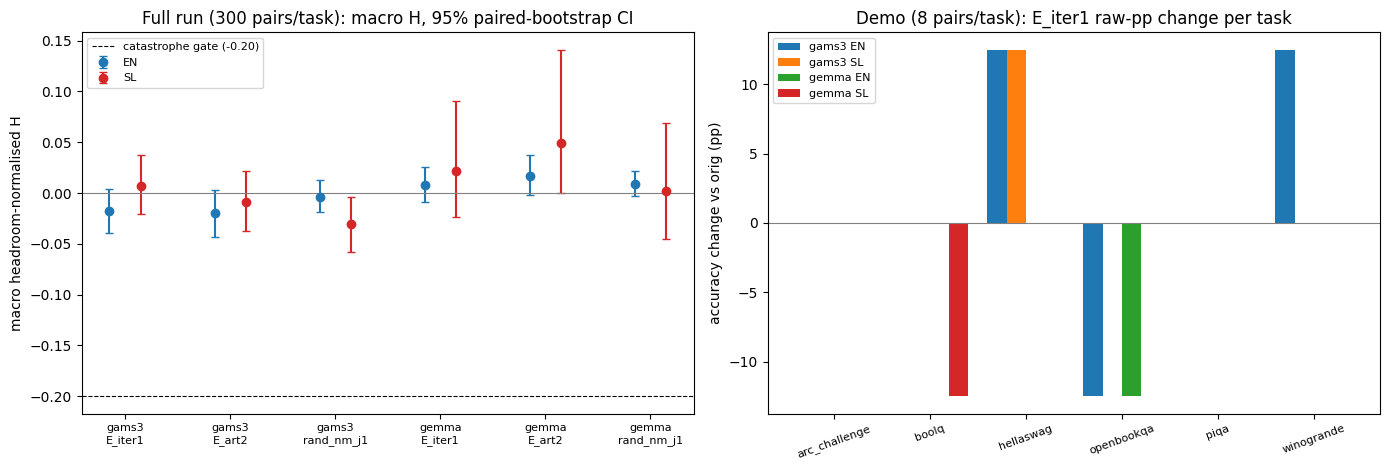

In [13]:
ref = data["full_run_reference"]
rows = []
for m in util["macros"]:
    for c, d in util["macros"][m].items():
        r_ = ref["macros"].get(m, {}).get(c, {})
        rows.append({"model": m, "cond": c,
                     "H_EN demo": d.get("en", {}).get("macro_H"), "H_SL demo": d.get("sl", {}).get("macro_H"),
                     "A demo": d.get("A_sl_minus_en"), "gate demo": gates[m][c]["verdict"],
                     "H_EN full": r_.get("en", {}).get("macro_H"), "H_SL full": r_.get("sl", {}).get("macro_H"),
                     "A full": r_.get("A_sl_minus_en"), "gate full": ref["gates"].get(m, {}).get(c)})
df = pd.DataFrame(rows).sort_values(["model", "cond"]).reset_index(drop=True)
pd.set_option("display.width", 200)
print(df.to_string(float_format=lambda x: f"{x:+.3f}"))

print("\nInteraction I = A_GaMS - A_Gemma (demo vs full run):")
for c in sorted(set(util["interaction"]) | set(ref["interaction"])):
    dmo, ful = util["interaction"].get(c, {}), ref["interaction"].get(c, {})
    print(f"  {c:12s} demo I={dmo.get('I', float('nan')):+.3f} {dmo.get('I_ci95')}   full I={ful.get('I', float('nan')):+.3f} {ful.get('I_ci95')}")

# figure 1: full-run macro H (EN vs SL) with 95% CIs; figure 2: demo raw-pp change per task for E_iter1
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
labels, k = [], 0
for m in ("gams3_it", "gemma_it"):
    for c in ("E_iter1", "E_art2", "rand_nm_j1"):
        r_ = ref["macros"].get(m, {}).get(c)
        if not r_:
            continue
        for j, (l, col) in enumerate((("en", "tab:blue"), ("sl", "tab:red"))):
            h, (lo, hi) = r_[l]["macro_H"], r_[l]["macro_H_ci95"]
            ax.errorbar(k + (j - 0.5) * 0.3, h, yerr=[[h - lo], [hi - h]], fmt="o", color=col, capsize=3,
                        label=l.upper() if k == 0 else None)
        labels.append(f"{m.split('_')[0]}\n{c}")
        k += 1
ax.axhline(0, color="grey", lw=0.8)
ax.axhline(-GATE_LOSS, color="black", ls="--", lw=0.8, label="catastrophe gate (-0.20)")
ax.set_xticks(range(len(labels)), labels, fontsize=8)
ax.set_ylabel("macro headroom-normalised H")
ax.set_title("Full run (300 pairs/task): macro H, 95% paired-bootstrap CI")
ax.legend(fontsize=8)

ax = axes[1]
w = 0.2
for i, (m, l) in enumerate([(m, l) for m in ("gams3_it", "gemma_it") for l in ("en", "sl")]):
    cells_ = util["cells"].get(m, {}).get("E_iter1", {}).get(l, {})
    ax.bar(np.arange(len(UTIL_TASKS)) + (i - 1.5) * w, [cells_.get(t, {}).get("raw_pp", np.nan) for t in UTIL_TASKS],
           width=w, label=f"{m.split('_')[0]} {l.upper()}")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(range(len(UTIL_TASKS)), UTIL_TASKS, rotation=20, fontsize=8)
ax.set_ylabel("accuracy change vs orig (pp)")
ax.set_title(f"Demo ({N_PAIRS_PER_TASK} pairs/task): E_iter1 raw-pp change per task")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()